In [2]:
import numpy as np
import matplotlib.pyplot as plt

MTs = np.load("/Volumes/data/Sasaki/backup_git/MTCargo_analysis/experiment/20251226/MC00MT/MTs.npy")

MT_mean = np.mean(MTs, axis=0)

MTs_bg = MTs - MT_mean

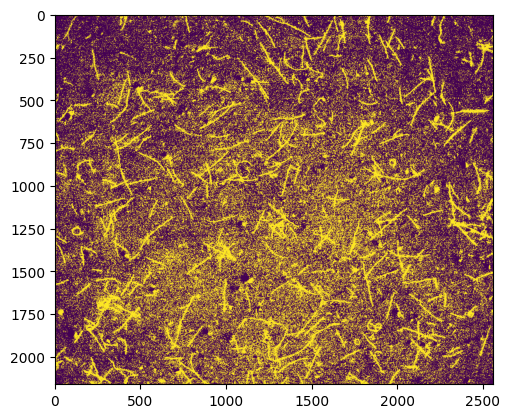

In [ ]:
from skimage.filters import threshold_otsu

thresh = threshold_otsu(MTs_bg[800])

images_bin = MTs_bg[800] > thresh

plt.imshow(images_bin)

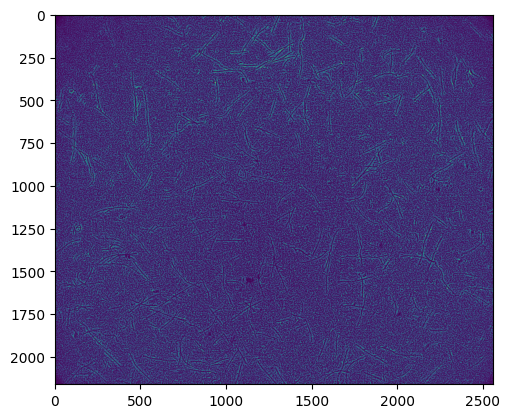

In [13]:
from skimage import filters

meijering_result = filters .meijering(MTs_bg[1000], sigmas=range(1, 4))
plt.imshow(meijering_result)

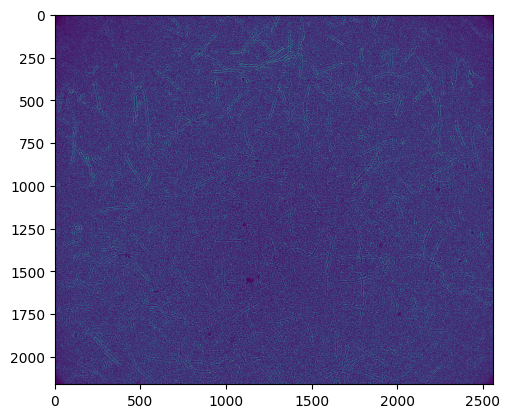

In [ ]:
sato_result = filters .sato(MTs_bg[1000], sigmas=range(1, 3))

plt.imshow(sato_result)

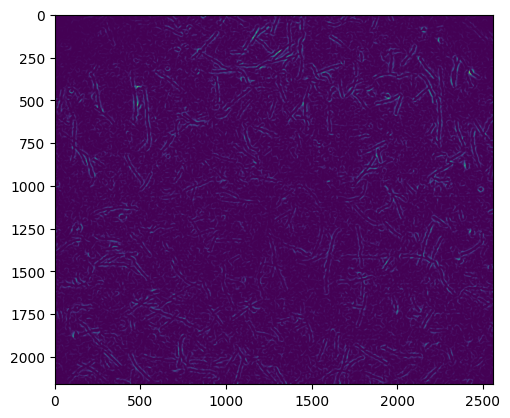

In [17]:
frangi_result = filters .frangi(MTs_bg[1000], sigmas=range(5, 20))
plt.imshow(frangi_result)

In [ ]:
from skimage.filters import threshold_otsu

thresh = threshold_otsu(MTs_bg)
images_bin = MTs_bg > thresh

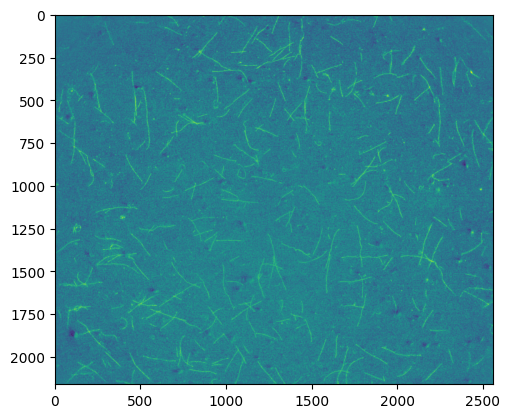

In [ ]:
plt.imshow(images_bin[1000])

In [5]:
from skimage.filters import threshold_local
from tqdm import tqdm

def threshold_image(image, block_size):
    """
    画像を局所的に二値化する
    """
    threshold = threshold_local(image, block_size=block_size, method='gaussian', param=1)
    binary_image = image > threshold
    return binary_image

def threshold_images(images, block_size):
    """
    3D画像スタックを局所的に二値化する
    """
    binary_images = np.empty_like(images, dtype=bool)
    for i in tqdm(range(images.shape[0])):
        binary_images[i] = threshold_image(images[i], block_size)
    return binary_images

scale = 0.11

block_size = 10 / scale

bin = threshold_images(MTs, block_size)

  0%|          | 0/1001 [00:00<?, ?it/s]

100%|██████████| 1001/1001 [01:00<00:00, 16.52it/s]


In [17]:
import os
import sys

pf2_val = np.load(r'/Volumes/data/Sasaki/backup_git/MTCargo_analysis/experiment/20251226/MC00MT001/MTs_pf.npy')

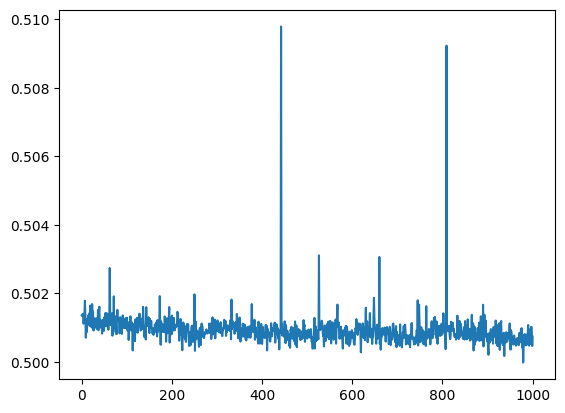

In [ ]:

plt.plot(range(len(pf2_val)), pf2_val)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import os
import sys

sys.path.append(os.path.abspath(".."))

from libs import displacement as dpm
from libs import fit_model as fm
from libs import cal_vel as cv

plt.style.use('../libs/my_style.mplstyle')

markers = ["o", "s", "v", "^", '*', 'd']
lines = ["-", "--", "-.", ":", (0, (5, 3, 1, 3, 1, 3))]

path = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20251225/MC03MT_low/beads_tracks.csv"
interval_h = 2
scale = 0.11

track1 = cv.cal(pd.read_csv(path), scale, interval_h)

/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tracking_df[cols_to_assign] = tracking_df.groupby('particle').apply(


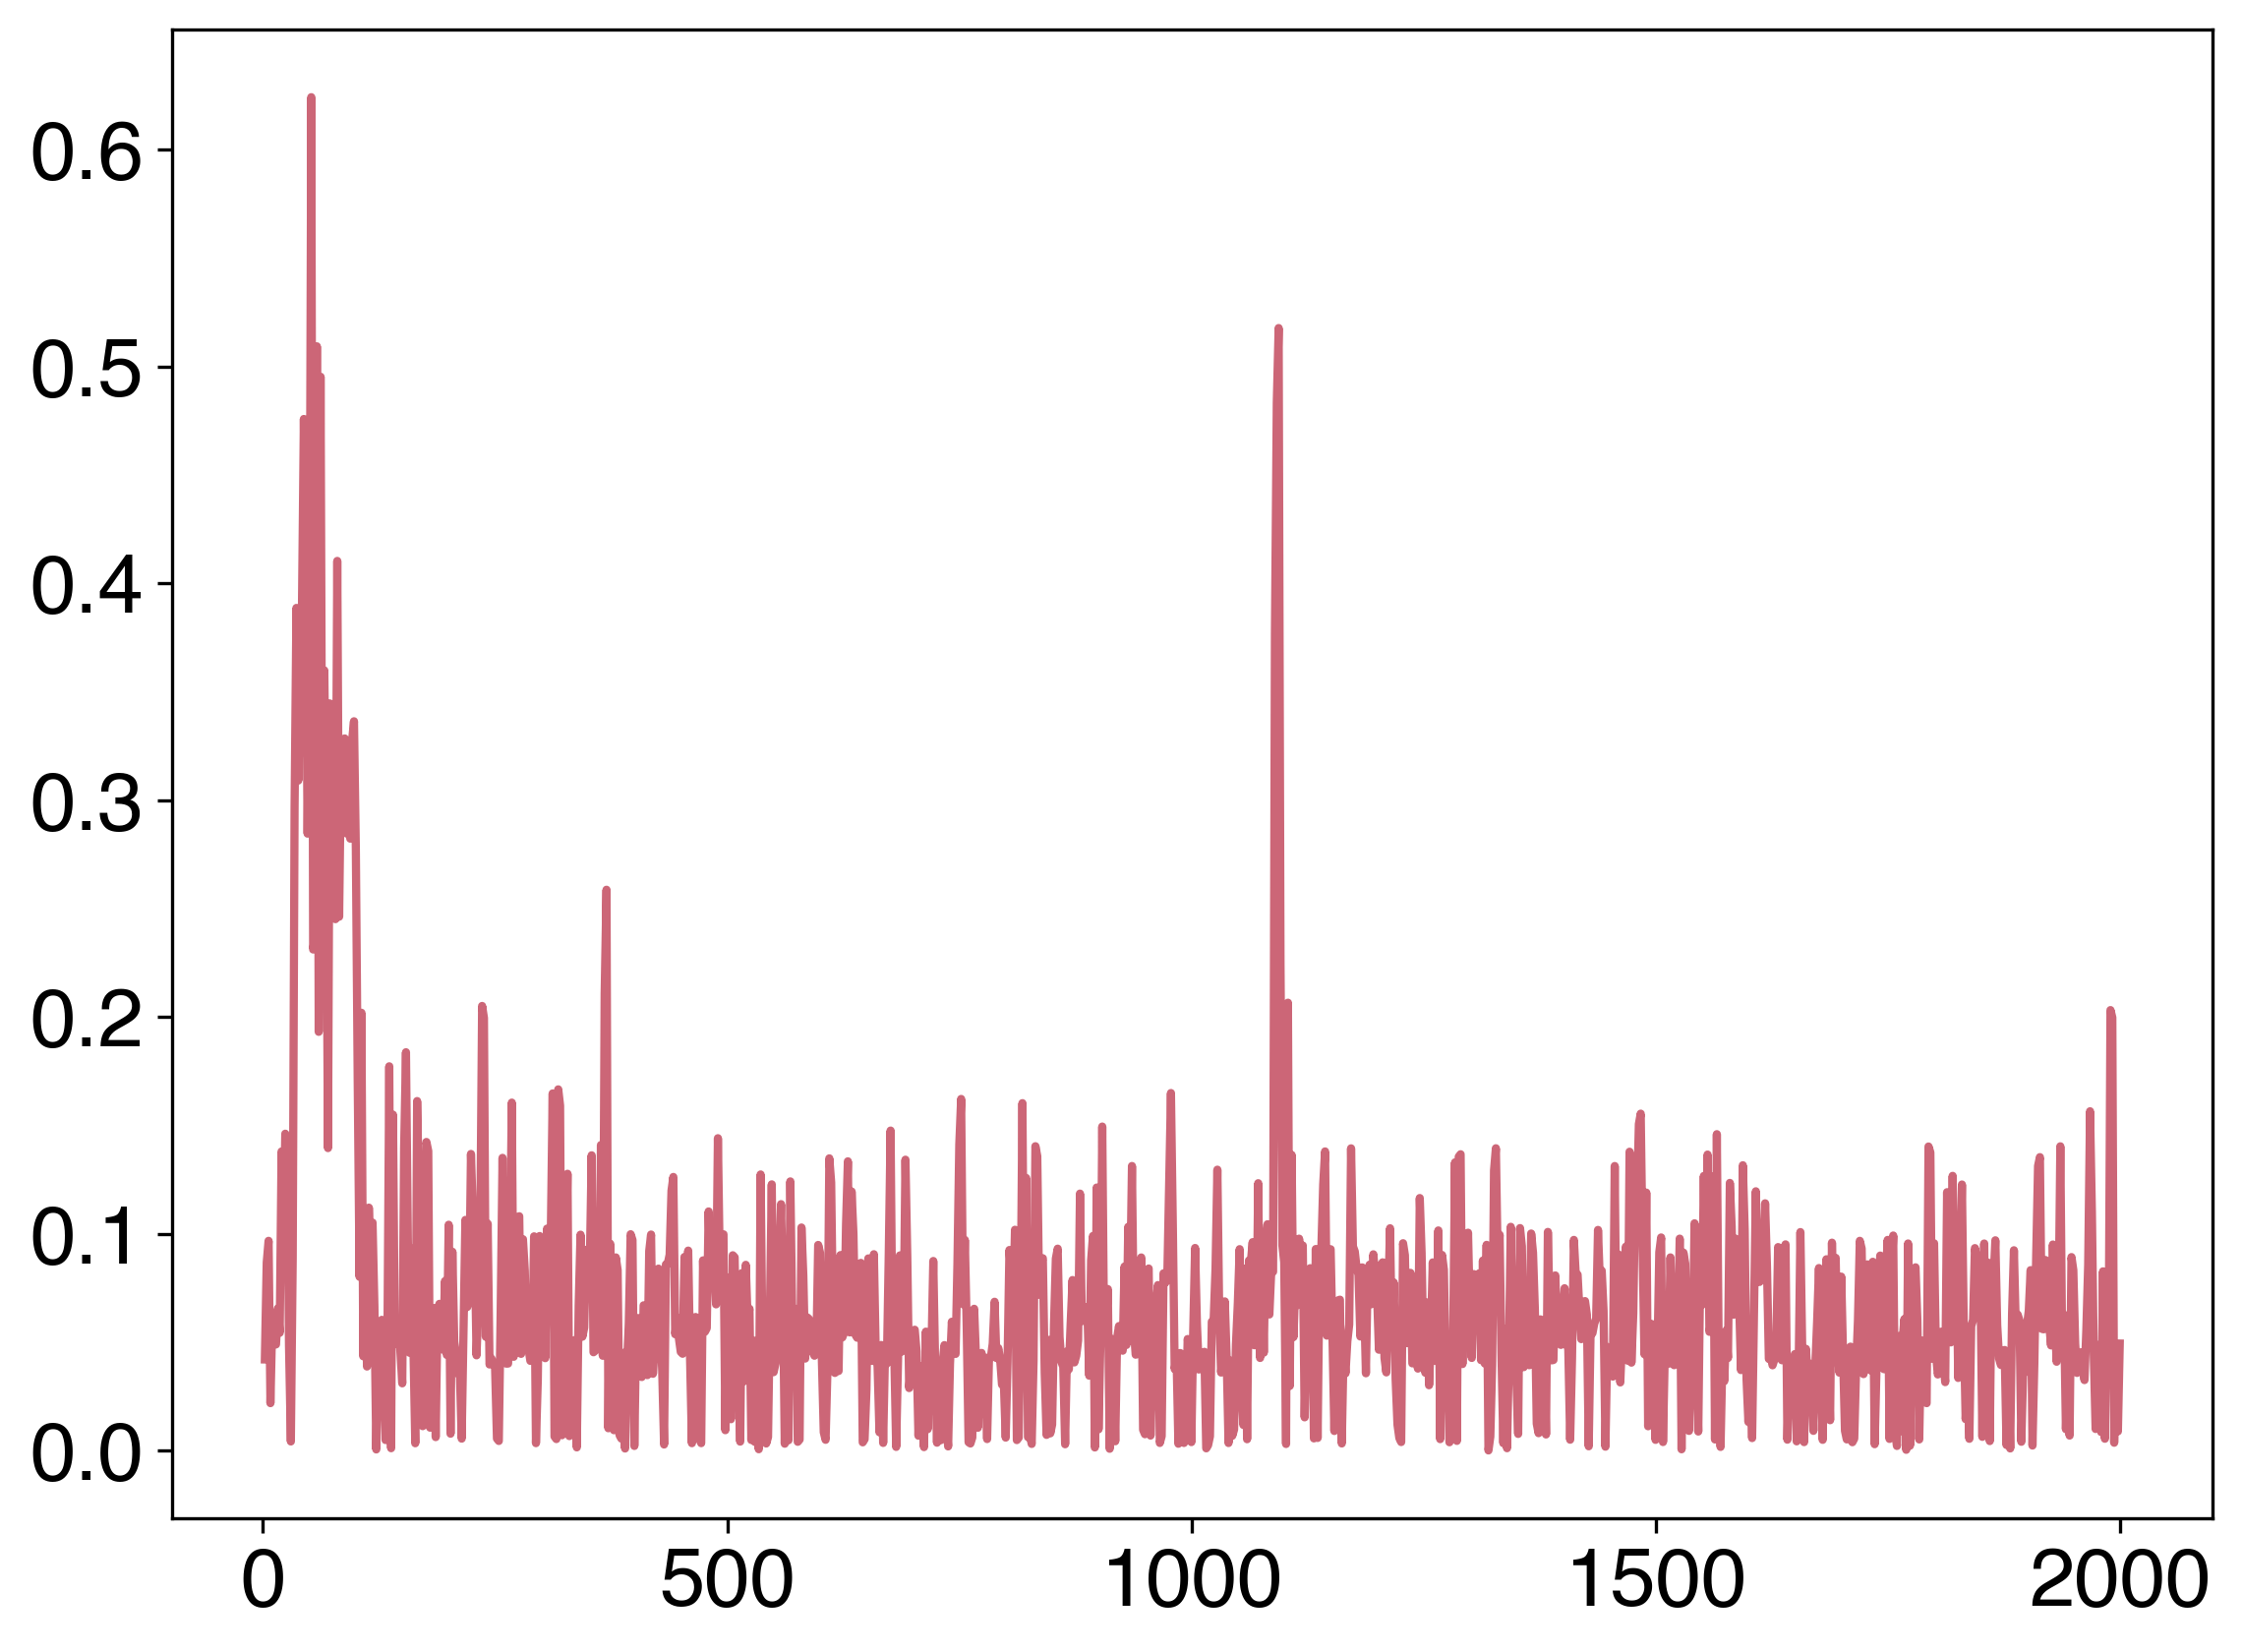

In [2]:
single = track1[track1['particle'] == 28]



v = single['v']
t = single['t']

fig, ax = plt.subplots()

ax.plot(t,v)

In [3]:
track1

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle,v,theta,alpha,t,dtheta,omega
0,1852.400876,979.608598,218.016333,3.411397,0.101115,4.242168,1566.0,0.005912,0,5,NaN,NaN,NaN,0,NaN,NaN
1,1621.211312,1927.962799,220.303994,3.368832,0.024498,4.464271,1887.0,0.004564,0,7,NaN,NaN,NaN,0,NaN,NaN
2,1156.772229,1184.033490,226.811613,3.382230,0.031163,4.419850,1489.0,0.006363,0,9,NaN,NaN,NaN,0,NaN,NaN
3,1052.477481,1042.963052,101.589925,3.422226,0.069984,2.176610,779.0,0.021431,0,13,NaN,NaN,NaN,0,NaN,NaN
4,901.823694,950.941582,190.097982,3.428385,0.021610,3.464807,1294.0,0.007886,0,15,NaN,NaN,NaN,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18205,268.177619,481.558427,168.212012,3.428599,0.038242,3.098764,1049.0,0.011398,1000,1560,0.178249,-0.059116,0.229554,2000,2.564253,1.282127
18206,252.986556,1803.845809,278.657513,3.458059,0.028852,4.717521,1832.0,0.004800,1000,28,0.049445,1.624452,1.817415,2000,2.755668,1.377834
18207,170.189081,693.956511,195.684637,3.448510,0.076014,3.561266,2026.0,0.004198,1000,2403,0.067099,-0.698216,-0.370496,2000,2.486154,1.243077
18208,1138.421220,2086.493127,262.423690,3.356768,0.062900,5.226274,1496.0,0.006386,1000,527,0.117711,-1.540652,-1.546729,2000,-3.129439,-1.564720


/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:349: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[new_column] = rolling_mean_series(s, window, center=center, min_periods=min_periods)
/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:349: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[new_column] = rolling_mean_series(s, window, center=center, min_periods=min_periods)
/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:349: SettingWithCopyWarning: 
A value is trying to be set on

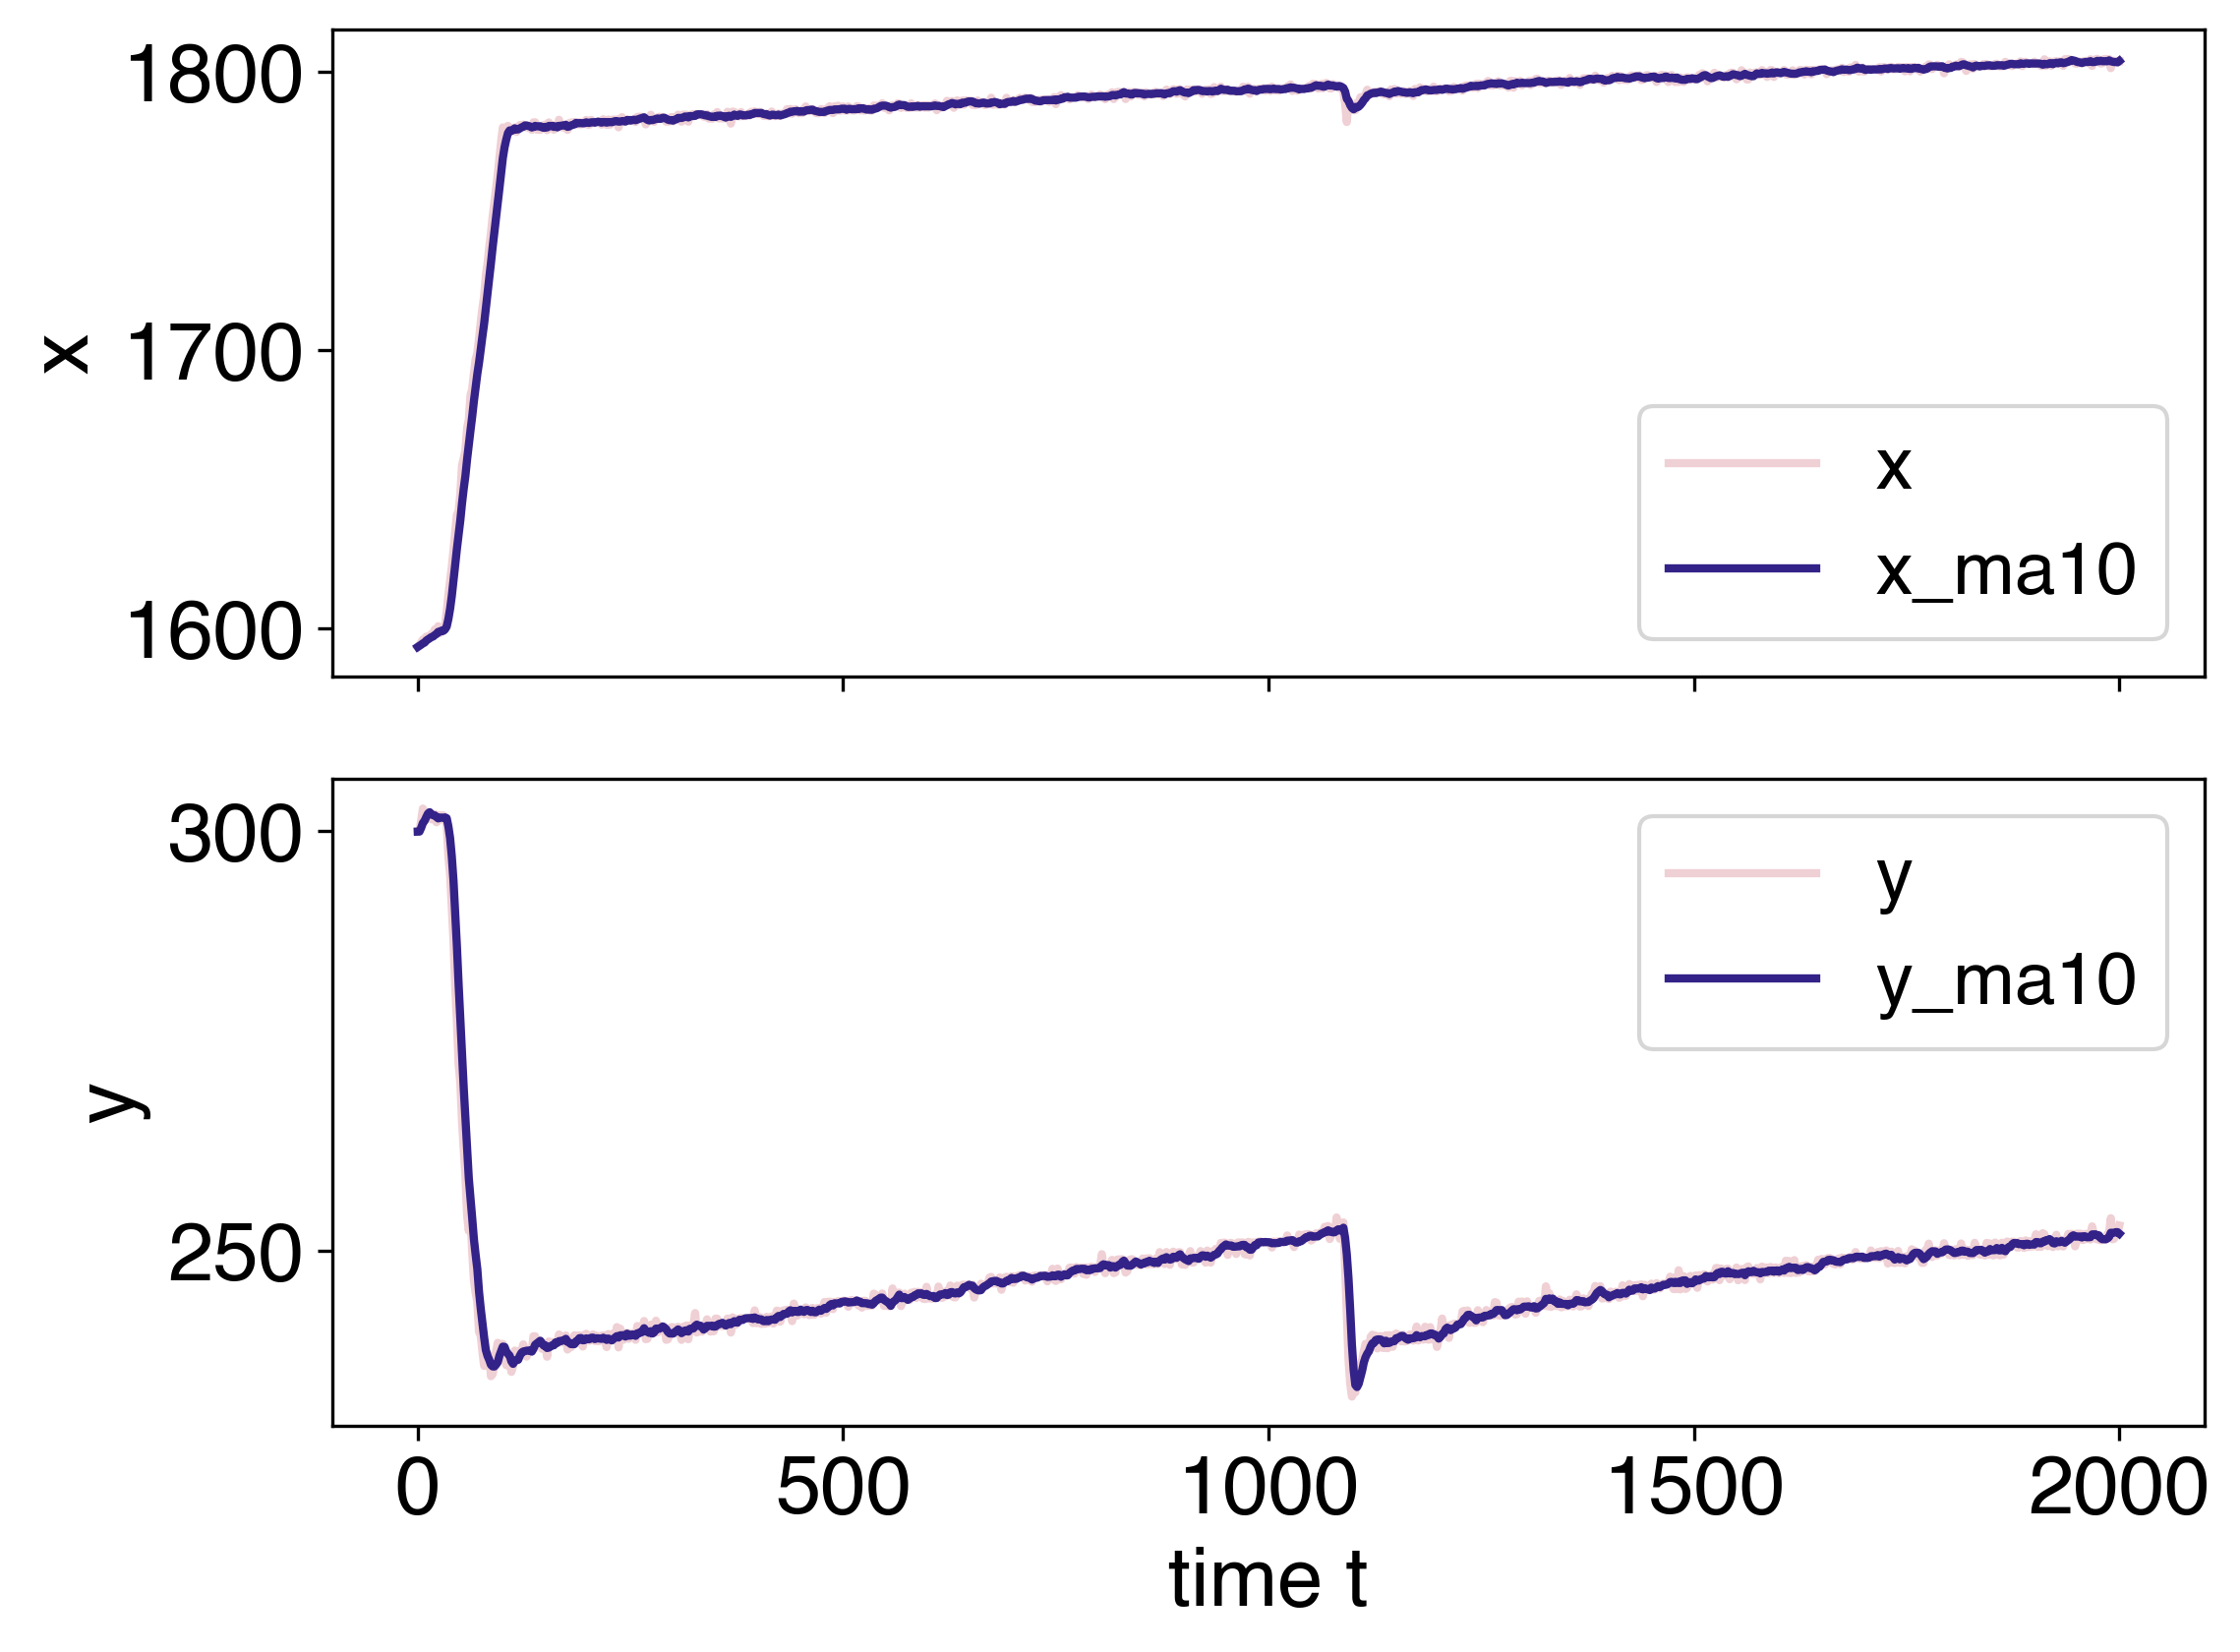

In [4]:
# Example: 移動平均の適用例
# - v: 線形移動平均
# - theta: 円形（角度）移動平均

single = track1[track1['particle'] == 28]

cv.moving_average(single, 'v', window=10, method='linear', new_column='v_ma10')
cv.moving_average(single, 'x', window=5, method='linear', new_column='x_ma10')
cv.moving_average(single, 'y', window=5, method='linear', new_column='y_ma10')

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axs[0].plot(single['t'], single['x'], alpha=0.3, label='x')
axs[0].plot(single['t'], single['x_ma10'], lw=2, label='x_ma10')
axs[0].set_ylabel('x')
axs[0].legend()

axs[1].plot(single['t'], single['y'], alpha=0.3, label='y')
axs[1].plot(single['t'], single['y_ma10'], lw=2, label='y_ma10')
axs[1].set_ylabel('y')
axs[1].legend()

plt.xlabel('time t')
plt.tight_layout()
plt.show()

/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tracking_df[cols_to_assign] = tracking_df.groupby('particle').apply(
/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tracking_df[cols_to_assign] = tracking_df.groupby('particle').apply(


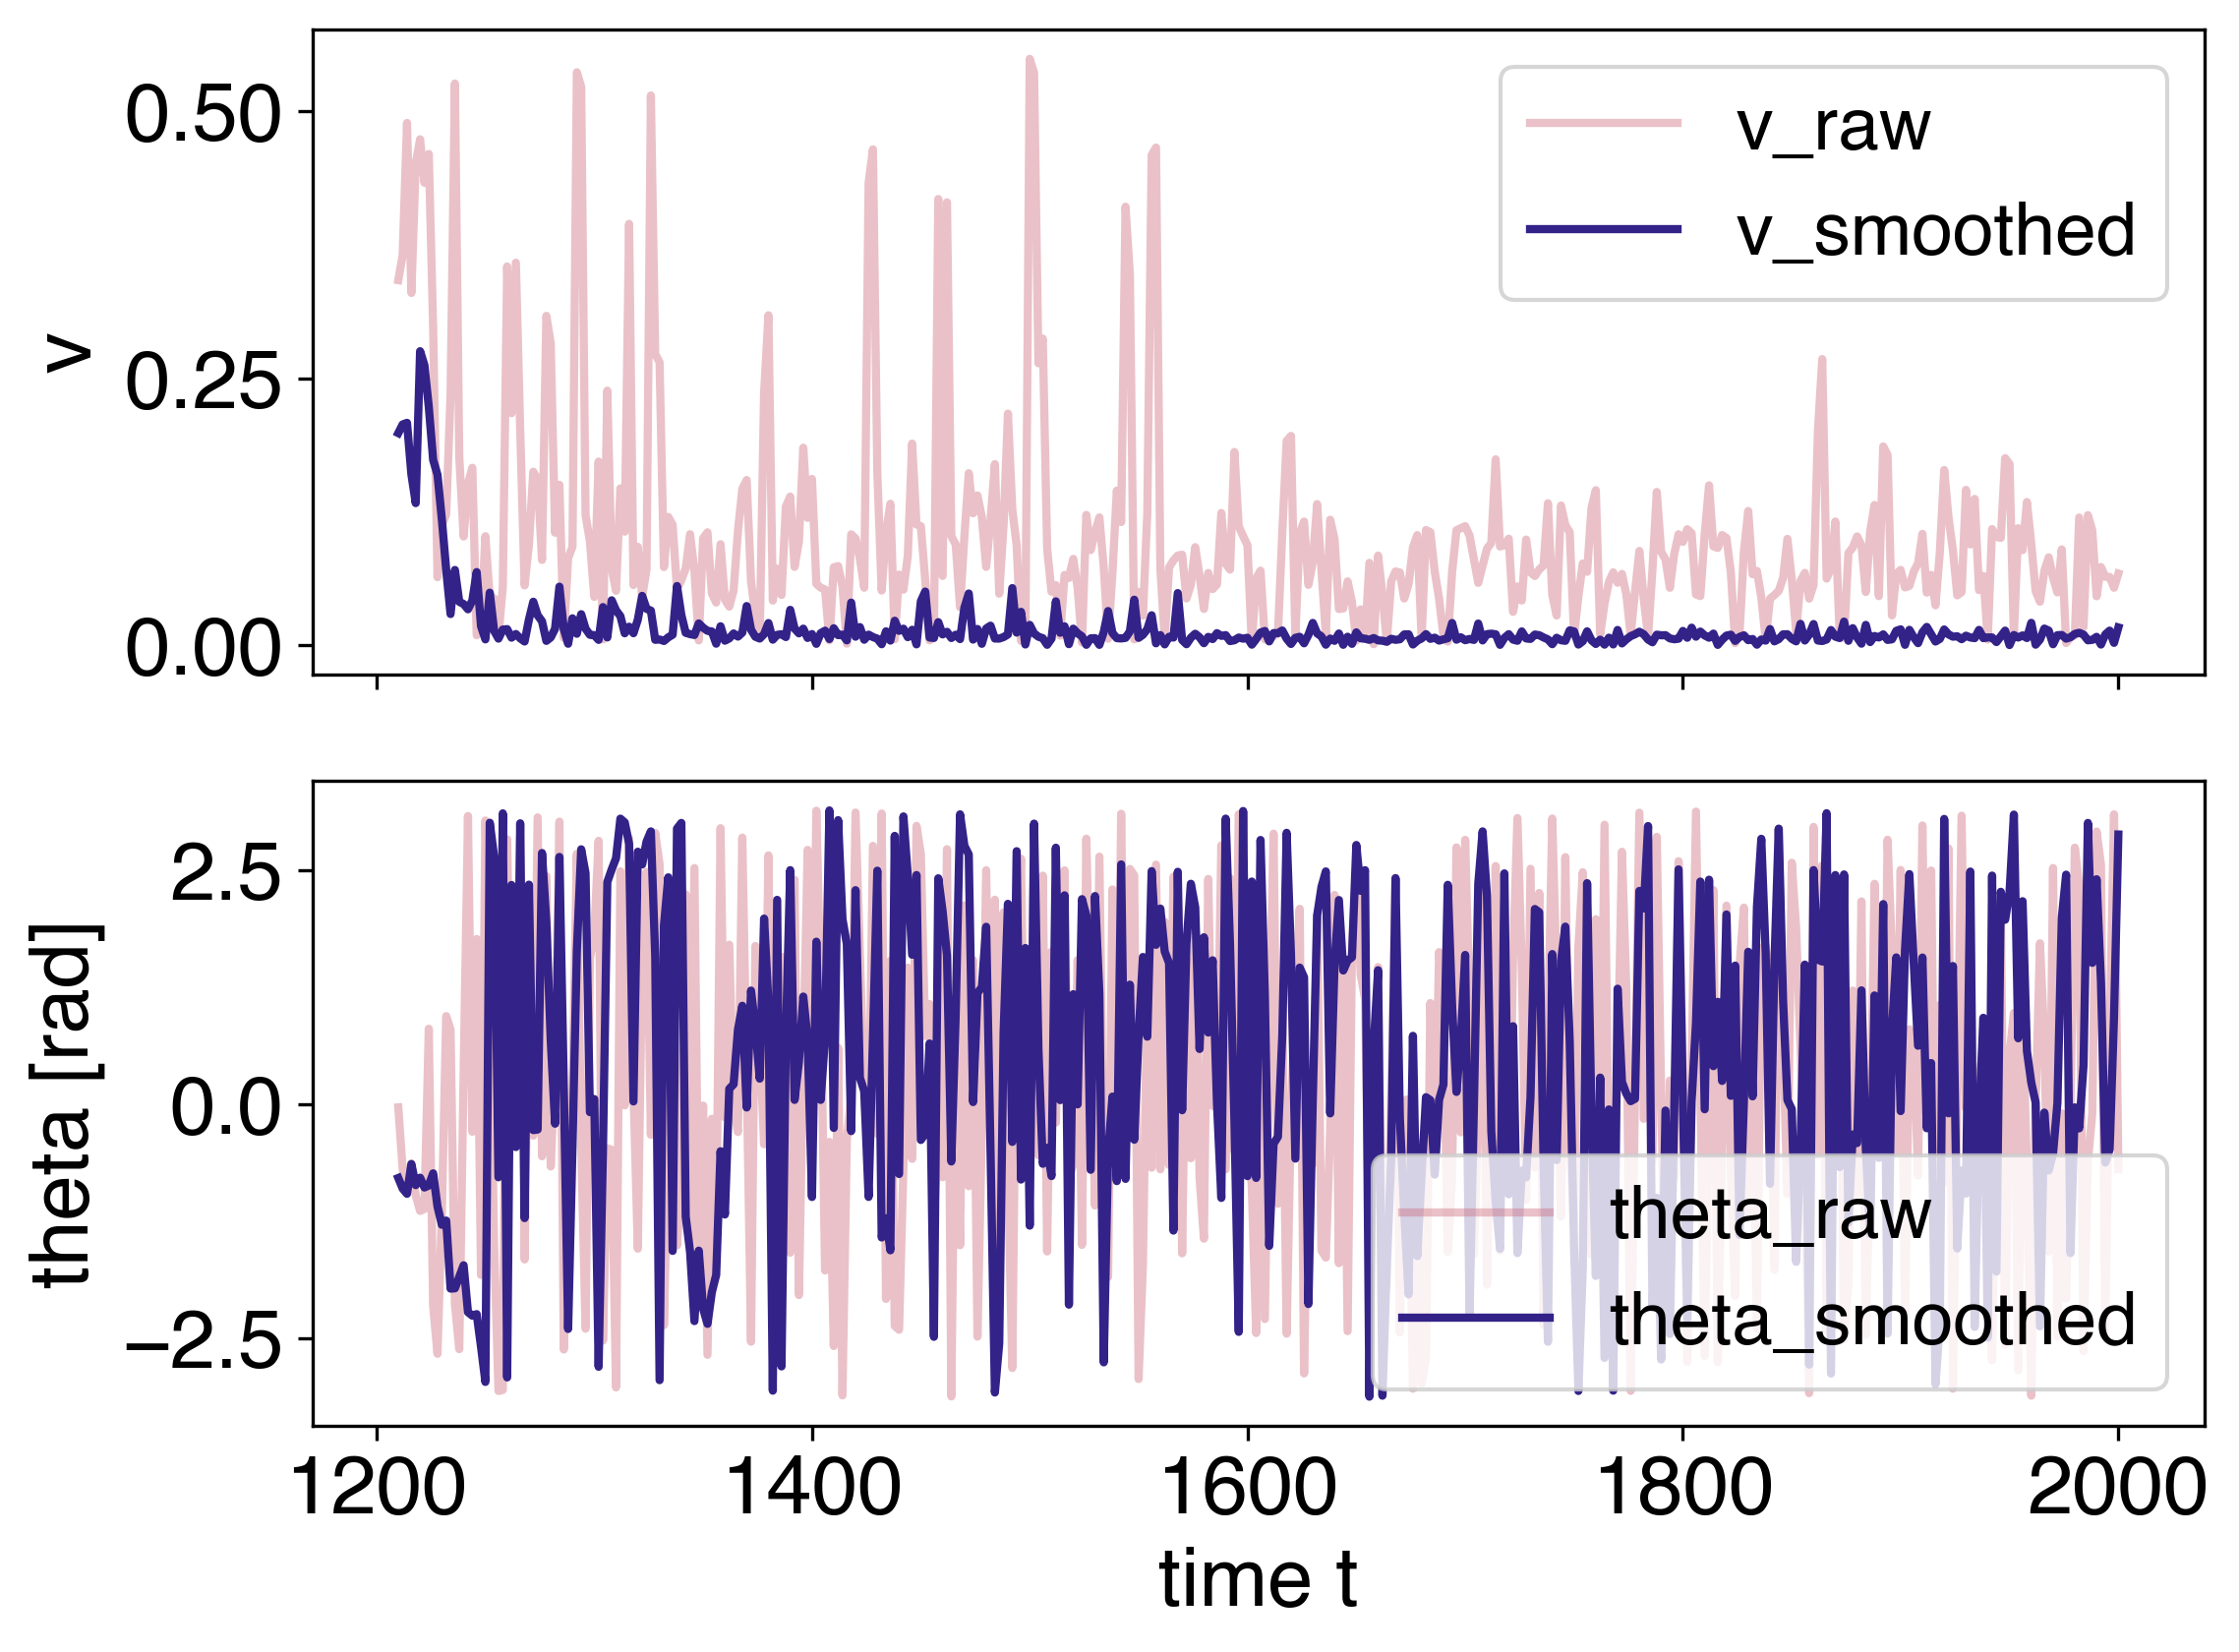

           x_s          y_s
0   979.591298  1852.891364
1  1927.607905  1621.791041
2  1183.598154  1156.616064
3  1043.368928  1049.911932
4   950.883460   901.710389


In [14]:
# Compare raw vs smoothed position -> velocity/angle
df_raw = cv.cal(pd.read_csv(path), scale, interval_h)
df_s = cv.cal(pd.read_csv(path), scale, interval_h, pos_window=10, pos_center=True)

p=2403

single_raw = df_raw[df_raw['particle'] == p]
single_s = df_s[df_s['particle'] == p]

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axs[0].plot(single_raw['t'], single_raw['v'], alpha=0.4, label='v_raw')
axs[0].plot(single_s['t'], single_s['v'], lw=2, label='v_smoothed')
axs[0].set_ylabel('v')
axs[0].legend()

axs[1].plot(single_raw['t'], single_raw['theta'], alpha=0.4, label='theta_raw')
axs[1].plot(single_s['t'], single_s['theta'], lw=2, label='theta_smoothed')
axs[1].set_ylabel('theta [rad]')
axs[1].legend()

plt.xlabel('time t')
plt.tight_layout()
plt.show()

# Check that smoothed positions are present
print(df_s[['x_s','y_s']].head())

In [13]:
df_s

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle,v,theta,alpha,t,dtheta,omega,x_s,y_s
0,1852.400876,979.608598,218.016333,3.411397,0.101115,4.242168,1566.0,0.005912,0,5,NaN,NaN,NaN,0,NaN,NaN,979.591298,1852.891364
1,1621.211312,1927.962799,220.303994,3.368832,0.024498,4.464271,1887.0,0.004564,0,7,NaN,NaN,NaN,0,NaN,NaN,1927.607905,1621.791041
2,1156.772229,1184.033490,226.811613,3.382230,0.031163,4.419850,1489.0,0.006363,0,9,NaN,NaN,NaN,0,NaN,NaN,1183.598154,1156.616064
3,1052.477481,1042.963052,101.589925,3.422226,0.069984,2.176610,779.0,0.021431,0,13,NaN,NaN,NaN,0,NaN,NaN,1043.368928,1049.911932
4,901.823694,950.941582,190.097982,3.428385,0.021610,3.464807,1294.0,0.007886,0,15,NaN,NaN,NaN,0,NaN,NaN,950.883460,901.710389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18205,268.177619,481.558427,168.212012,3.428599,0.038242,3.098764,1049.0,0.011398,1000,1560,0.004136,-0.213375,-0.070515,2000,2.855871,1.427936,479.649237,268.806108
18206,252.986556,1803.845809,278.657513,3.458059,0.028852,4.717521,1832.0,0.004800,1000,28,0.008889,2.969766,-2.218234,2000,0.951222,0.475611,1803.450205,252.319902
18207,170.189081,693.956511,195.684637,3.448510,0.076014,3.561266,2026.0,0.004198,1000,2403,0.016647,2.883252,-2.802232,2000,1.946189,0.973094,693.867321,170.569144
18208,1138.421220,2086.493127,262.423690,3.356768,0.062900,5.226274,1496.0,0.006386,1000,527,0.003840,2.157185,3.030749,2000,1.394466,0.697233,2086.810752,1138.725739
